# 📊 MIS Cobrança Performance
## 02 - Análise Exploratória de Dados (EDA)

### 🎯 Objetivo
Transformar dados operacionais em inteligência estratégica, analisando:

- Estrutura da carteira
- Perfil de atraso
- Volume de acionamentos
- Performance por operador
- Eficiência por canal
- Indicadores de recuperação

Este notebook combina visão técnica e executiva.


In [10]:
# ==========================================================
# 📦 IMPORTAÇÃO DE BIBLIOTECAS
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")


In [11]:
# ==========================================================
# 📂 CARREGAMENTO DAS BASES
# ==========================================================

clientes = pd.read_csv("../data/raw/carteira_clientes.csv")
acionamentos = pd.read_csv("../data/raw/acionamentos.csv")
pagamentos = pd.read_csv("../data/raw/pagamentos.csv")

print("Clientes:", clientes.shape)
print("Acionamentos:", acionamentos.shape)
print("Pagamentos:", pagamentos.shape)


Clientes: (10000, 7)
Acionamentos: (35000, 5)
Pagamentos: (3297, 3)


Valor total da carteira: R$ 47,550,184.45
Ticket médio da dívida: R$ 4,755.02


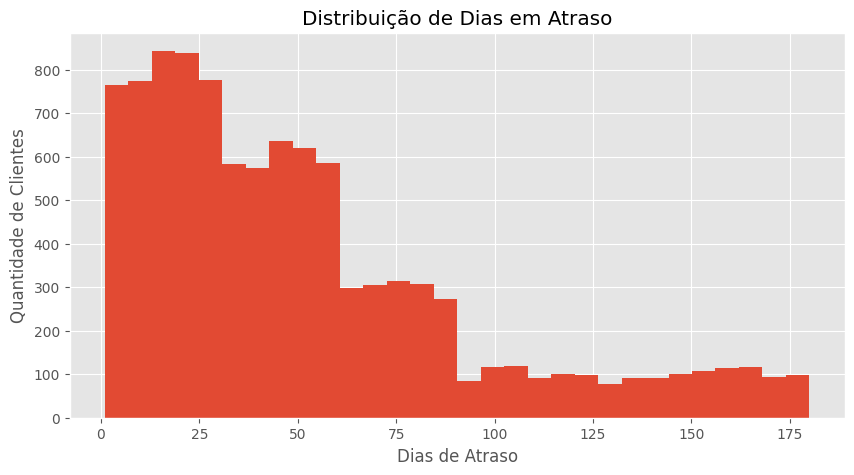

In [20]:
# ==========================================================
# 💰 ANÁLISE DA CARTEIRA
# ==========================================================

valor_total_carteira = clientes["valor_divida"].sum()
ticket_medio = clientes["valor_divida"].mean()

print(f"Valor total da carteira: R$ {valor_total_carteira:,.2f}")
print(f"Ticket médio da dívida: R$ {ticket_medio:,.2f}")

plt.figure(figsize=(10,5))
plt.hist(clientes["dias_atraso"], bins=30)
plt.title("Distribuição de Dias em Atraso")
plt.xlabel("Dias de Atraso")
plt.ylabel("Quantidade de Clientes")
plt.show()


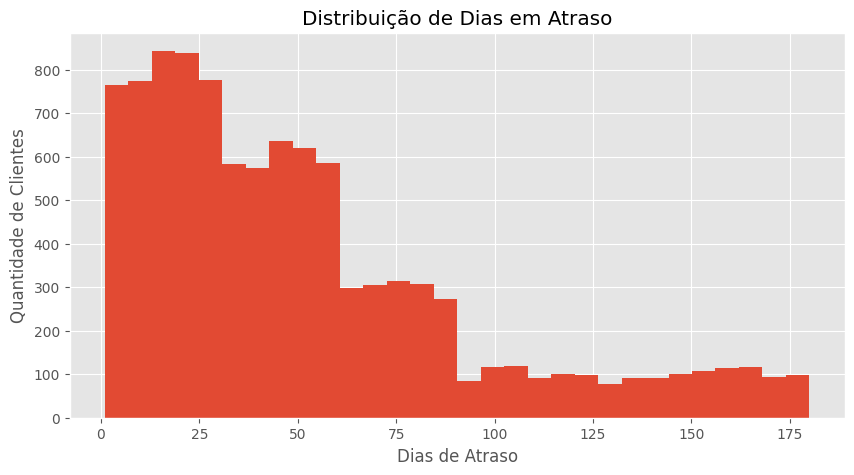

In [21]:
plt.figure(figsize=(10,5))
plt.hist(clientes["dias_atraso"], bins=30)
plt.title("Distribuição de Dias em Atraso")
plt.xlabel("Dias de Atraso")
plt.ylabel("Quantidade de Clientes")
plt.show()


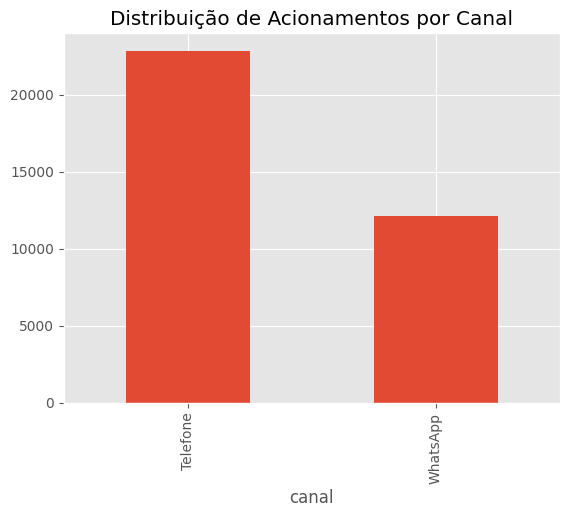

In [22]:
canal_dist = acionamentos["canal"].value_counts()

canal_dist.plot(kind="bar")
plt.title("Distribuição de Acionamentos por Canal")
plt.show()


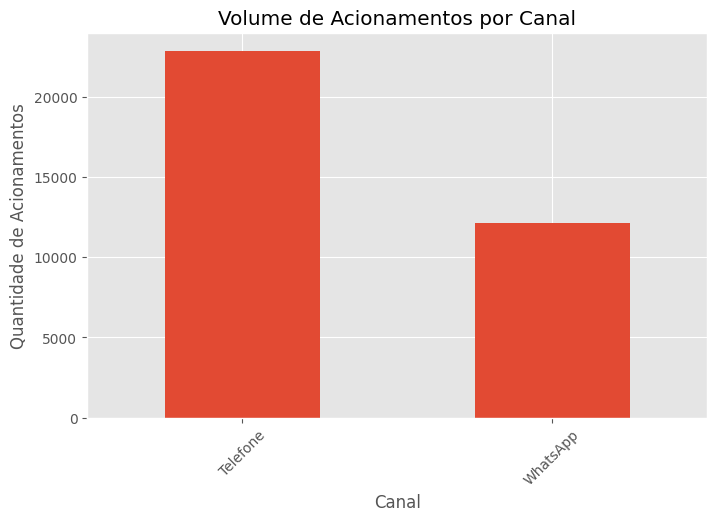

In [28]:
performance_canal = (
    acionamentos
    .groupby("canal")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
performance_canal.plot(kind="bar")
plt.title("Volume de Acionamentos por Canal")
plt.xlabel("Canal")
plt.ylabel("Quantidade de Acionamentos")
plt.xticks(rotation=45)
plt.show()

In [29]:
valor_total_pago = pagamentos["valor_pago"].sum()
ticket_medio_pago = pagamentos["valor_pago"].mean()

print(f"Valor total recuperado: R$ {valor_total_pago:,.2f}")
print(f"Ticket médio pago: R$ {ticket_medio_pago:,.2f}")


Valor total recuperado: R$ 10,990,125.44
Ticket médio pago: R$ 3,333.37


In [31]:
taxa_recuperacao = (valor_total_pago / valor_total_carteira) * 100

print(f"Taxa de Recuperação: {taxa_recuperacao:.2f}%")


Taxa de Recuperação: 23.11%


In [33]:
# ==========================================================
# 📞 TAXA DE CONTATO EFETIVO
# ==========================================================

taxa_contato = acionamentos["contato_efetivo"].mean() * 100

print(f"Taxa de Contato Efetivo: {taxa_contato:.2f}%")


Taxa de Contato Efetivo: 52.99%


In [34]:
# ==========================================================
# 🔗 CONSOLIDAÇÃO FINAL - NÍVEL CLIENTE
# ==========================================================

# Agregação de acionamentos
acionamentos_agg = (
    acionamentos
    .groupby("cliente_id")
    .agg(
        total_acionamentos=("cliente_id", "count"),
        taxa_contato=("contato_efetivo", "mean"),
        taxa_promessa=("promessa_pagamento", "mean")
    )
    .reset_index()
)

# Agregação de pagamentos
pagamentos_agg = (
    pagamentos
    .groupby("cliente_id")
    .agg(
        total_pago=("valor_pago", "sum"),
        qtd_pagamentos=("valor_pago", "count")
    )
    .reset_index()
)

# Merge final
base_consolidada = (
    clientes
    .merge(acionamentos_agg, on="cliente_id", how="left")
    .merge(pagamentos_agg, on="cliente_id", how="left")
)

# Tratamento de nulos
base_consolidada.fillna(0, inplace=True)

# Indicadores estratégicos
base_consolidada["cliente_recuperado"] = (
    base_consolidada["total_pago"] > 0
).astype(int)

base_consolidada["percentual_recuperado"] = (
    base_consolidada["total_pago"] / base_consolidada["valor_divida"]
)

# Exportação
base_consolidada.to_csv("../data/processed/base_consolidada.csv", index=False)

print("✅ Base consolidada criada com sucesso.")


✅ Base consolidada criada com sucesso.


# 📈 Insights Estratégicos

- Identificar concentração de dívida em faixas específicas de atraso
- Avaliar eficiência por canal
- Medir produtividade individual dos operadores
- Monitorar taxa de recuperação geral
- Avaliar taxa de contato efetivo

Essas análicas são base para:

✔ Definição de estratégia de cobrança  
✔ Redistribuição de carteira  
✔ Otimização de canais  
✔ Criação de metas operacionais  
✔ Construção de Dashboard Executivo  
